Mounted at /content/drive
(25059, 35)

Research Question:

How efficiently is the hospital operating,
and where are bottlenecks occurring?



HOSPITAL KPI DASHBOARD
Average LOS: 10.00
Median LOS: 10.00
Average ICU LOS: 3.99
Readmission Rate: 14.86%
Mortality Rate: 9.96%
Average Resource Score: 20.37
             Metric      Value
0       Average LOS  10.002793
1        Median LOS  10.000000
2   Average ICU LOS   3.991712
3  Readmission Rate   0.148609
4    Mortality Rate   0.099645
5    Resource Score  20.365338
  admission_type  admissions    avg_los  avg_resource  avg_icu_los  \
0       ELECTIVE        6332   9.993051     20.275111     3.985458   
1      EMERGENCY        6281   9.891896     20.427002     3.985814   
2    OBSERVATION        6236  10.067832     20.428801     4.009267   
3         URGENT        6210  10.059581     20.331240     3.986424   

   readmission_rate  mortality_rate  
0          0.144188        0.097126  
1          0.151727        0.099666  
2          0.1449

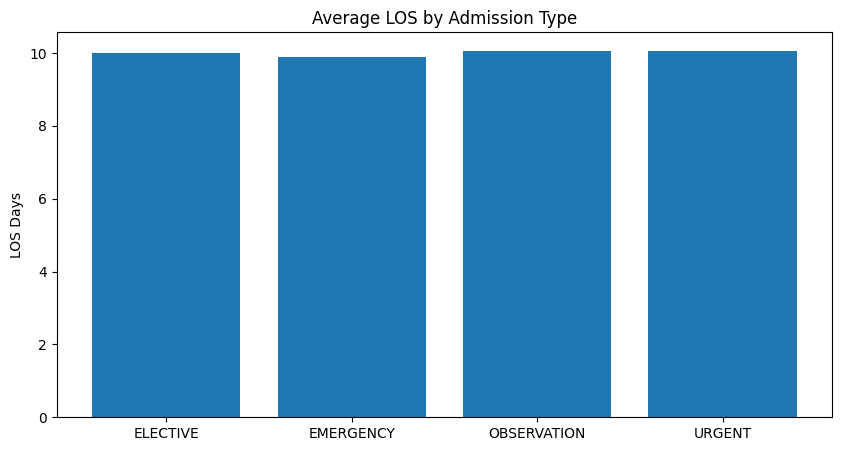

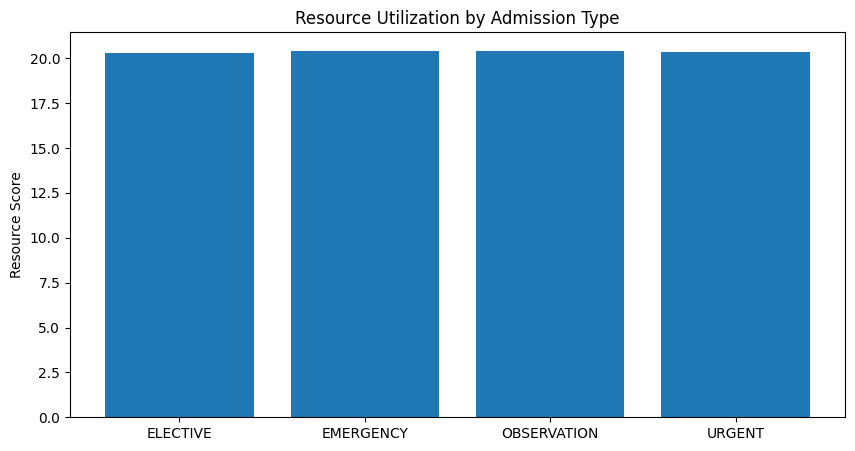

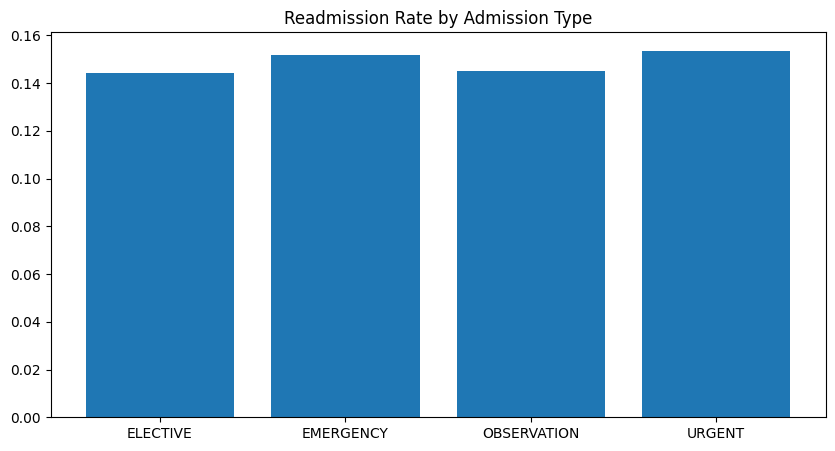

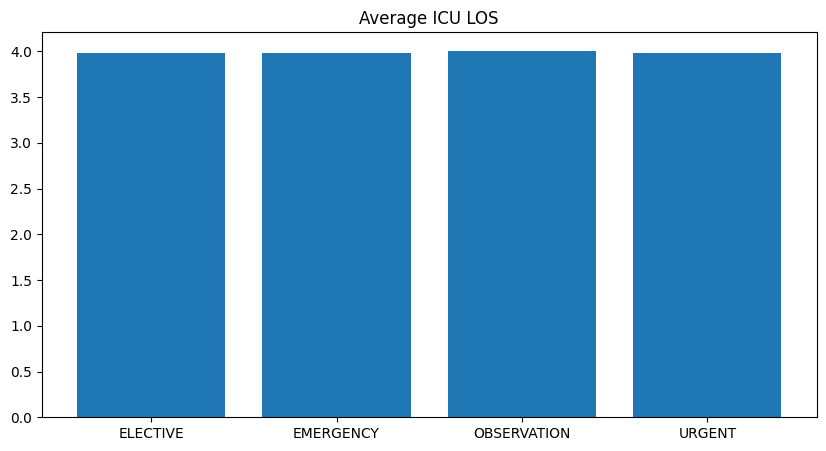


Top Resource Intensive Admissions
       hadm_id  resource_score  los_days  icu_los  mortality
807     200807              35        12     1.34          0
4460    204460              35        12     2.24          0
5595    205595              35        10     5.16          0
7189    207189              35        13     2.69          0
14707   214707              35         2     4.82          0
14783   214783              35        14     4.21          0
16691   216691              35        17     1.33          0
20000   220000              35        19     3.28          1
21904   221904              35        12     2.02          0
22559   222559              35         8     1.45          0
22943   222943              35         3     3.77          0
410     200410              34         6     3.76          0
451     200451              34         3     1.63          0
741     200741              34        12     2.67          0
1191    201191              34        15     1.35 

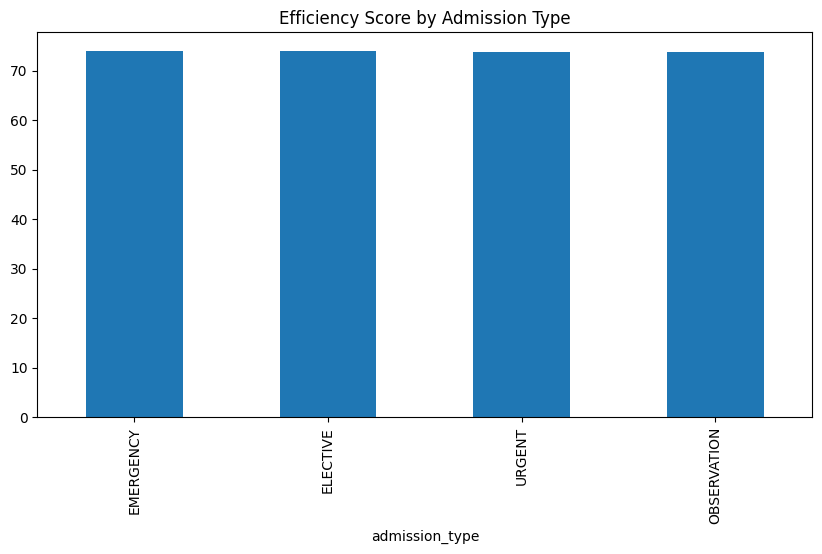



TOP BOTTLENECKS
  admission_type  admissions    avg_los  avg_resource  avg_icu_los  \
2    OBSERVATION        6236  10.067832     20.428801     4.009267   
3         URGENT        6210  10.059581     20.331240     3.986424   
0       ELECTIVE        6332   9.993051     20.275111     3.985458   
1      EMERGENCY        6281   9.891896     20.427002     3.985814   

   readmission_rate  mortality_rate  
2          0.144965        0.101988  
3          0.153623        0.099839  
0          0.144188        0.097126  
1          0.151727        0.099666  

Exports Complete

Created:

hospital_kpis.csv

operations_dashboard.csv

bottleneck_analysis.csv



EXECUTIVE SUMMARY


Potential Bottlenecks:

1. Highest LOS Admission Type

2. Highest Resource Consumption

3. Highest ICU Utilization

4. Highest Readmission Rate

5. Lowest Efficiency Score

Review the ranking tables above
to identify operational targets.




In [ ]:
# =====================================================
# NOTEBOOK 5
# HOSPITAL OPERATIONS ANALYTICS
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# LOAD DATA
# =====================================================

DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

master = pd.read_csv(
    f"{DATA_PATH}/master_dataset.csv"
)

print(master.shape)

master.head()

# =====================================================
# RESEARCH QUESTION
# =====================================================

print("""
Research Question:

How efficiently is the hospital operating,
and where are bottlenecks occurring?
""")

# =====================================================
# EXECUTIVE KPI DASHBOARD
# =====================================================

print("\n")
print("="*60)
print("HOSPITAL KPI DASHBOARD")
print("="*60)

avg_los = master["los_days"].mean()

median_los = master["los_days"].median()

avg_icu = master["icu_los"].mean()

readmission_rate = (
    master["readmit_30d"].mean()
)

mortality_rate = (
    master["mortality"].mean()
)

avg_resource = (
    master["resource_score"].mean()
)

print(f"Average LOS: {avg_los:.2f}")

print(f"Median LOS: {median_los:.2f}")

print(f"Average ICU LOS: {avg_icu:.2f}")

print(
    f"Readmission Rate: {readmission_rate:.2%}"
)

print(
    f"Mortality Rate: {mortality_rate:.2%}"
)

print(
    f"Average Resource Score: {avg_resource:.2f}"
)

# =====================================================
# KPI SCORECARD
# =====================================================

kpis = pd.DataFrame({

    "Metric":[
        "Average LOS",
        "Median LOS",
        "Average ICU LOS",
        "Readmission Rate",
        "Mortality Rate",
        "Resource Score"
    ],

    "Value":[
        avg_los,
        median_los,
        avg_icu,
        readmission_rate,
        mortality_rate,
        avg_resource
    ]

})

print(kpis)

# =====================================================
# ADMISSION TYPE ANALYSIS
# =====================================================

admission_analysis = (
    master.groupby(
        "admission_type"
    )
    .agg(
        admissions=(
            "hadm_id",
            "count"
        ),

        avg_los=(
            "los_days",
            "mean"
        ),

        avg_resource=(
            "resource_score",
            "mean"
        ),

        avg_icu_los=(
            "icu_los",
            "mean"
        ),

        readmission_rate=(
            "readmit_30d",
            "mean"
        ),

        mortality_rate=(
            "mortality",
            "mean"
        )
    )
    .reset_index()
)

print(admission_analysis)

# =====================================================
# LOS BOTTLENECKS
# =====================================================

los_rank = (
    admission_analysis
    .sort_values(
        "avg_los",
        ascending=False
    )
)

print("\nLOS Ranking")

print(los_rank)

# =====================================================
# RESOURCE BOTTLENECKS
# =====================================================

resource_rank = (
    admission_analysis
    .sort_values(
        "avg_resource",
        ascending=False
    )
)

print("\nResource Ranking")

print(resource_rank)

# =====================================================
# READMISSION BOTTLENECKS
# =====================================================

readmit_rank = (
    admission_analysis
    .sort_values(
        "readmission_rate",
        ascending=False
    )
)

print("\nReadmission Ranking")

print(readmit_rank)

# =====================================================
# ICU BOTTLENECKS
# =====================================================

icu_rank = (
    admission_analysis
    .sort_values(
        "avg_icu_los",
        ascending=False
    )
)

print("\nICU Ranking")

print(icu_rank)

# =====================================================
# VISUALIZATION
# LOS
# =====================================================

plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis[
        "admission_type"
    ],
    admission_analysis[
        "avg_los"
    ]
)

plt.title(
    "Average LOS by Admission Type"
)

plt.ylabel(
    "LOS Days"
)

plt.show()

# =====================================================
# RESOURCE UTILIZATION
# =====================================================

plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis[
        "admission_type"
    ],
    admission_analysis[
        "avg_resource"
    ]
)

plt.title(
    "Resource Utilization by Admission Type"
)

plt.ylabel(
    "Resource Score"
)

plt.show()

# =====================================================
# READMISSION RATE
# =====================================================

plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis[
        "admission_type"
    ],
    admission_analysis[
        "readmission_rate"
    ]
)

plt.title(
    "Readmission Rate by Admission Type"
)

plt.show()

# =====================================================
# ICU LOS
# =====================================================

plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis[
        "admission_type"
    ],
    admission_analysis[
        "avg_icu_los"
    ]
)

plt.title(
    "Average ICU LOS"
)

plt.show()

# =====================================================
# RESOURCE HOTSPOTS
# =====================================================

high_resource = master.nlargest(
    20,
    "resource_score"
)

print("\nTop Resource Intensive Admissions")

print(

    high_resource[[
        "hadm_id",
        "resource_score",
        "los_days",
        "icu_los",
        "mortality"
    ]]

)

# =====================================================
# LONGEST STAYS
# =====================================================

long_stays = master.nlargest(
    20,
    "los_days"
)

print("\nLongest LOS")

print(

    long_stays[[
        "hadm_id",
        "los_days",
        "resource_score",
        "icu_los"
    ]]

)

# =====================================================
# EFFICIENCY SCORE
# =====================================================

master["efficiency_score"] = (

    100

    -

    (
        master["los_days"] * 2
    )

    -

    (
        master["resource_score"] * 0.3
    )

)

print("\n")

print(
    "Average Efficiency Score"
)

print(
    master["efficiency_score"]
    .mean()
)

# =====================================================
# EFFICIENCY BY ADMISSION TYPE
# =====================================================

efficiency = (

    master.groupby(
        "admission_type"
    )["efficiency_score"]

    .mean()

    .sort_values(
        ascending=False
    )

)

print("\nEfficiency Ranking")

print(efficiency)

plt.figure(figsize=(10,5))

efficiency.plot(
    kind="bar"
)

plt.title(
    "Efficiency Score by Admission Type"
)

plt.show()

# =====================================================
# BOTTLENECK IDENTIFICATION
# =====================================================

bottlenecks = (

    admission_analysis

    .sort_values(
        [
            "avg_los",
            "avg_resource",
            "readmission_rate"
        ],
        ascending=False
    )

)

print("\n")
print("="*60)
print("TOP BOTTLENECKS")
print("="*60)

print(
    bottlenecks.head()
)

# =====================================================
# EXPORT TABLES
# =====================================================

admission_analysis.to_csv(

    f"{DATA_PATH}/operations_dashboard.csv",

    index=False

)

bottlenecks.to_csv(

    f"{DATA_PATH}/bottleneck_analysis.csv",

    index=False

)

kpis.to_csv(

    f"{DATA_PATH}/hospital_kpis.csv",

    index=False

)

print("\nExports Complete")

print("""
Created:

hospital_kpis.csv

operations_dashboard.csv

bottleneck_analysis.csv
""")

# =====================================================
# EXECUTIVE SUMMARY
# =====================================================

print("\n")
print("="*60)
print("EXECUTIVE SUMMARY")
print("="*60)

print("""

Potential Bottlenecks:

1. Highest LOS Admission Type

2. Highest Resource Consumption

3. Highest ICU Utilization

4. Highest Readmission Rate

5. Lowest Efficiency Score

Review the ranking tables above
to identify operational targets.

""")